**LOGISTIC REGRESSION**

IMPORT LIBRARIES :

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/diabetes.csv')


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Features, Data Types, Summary Statistics

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Visualizations

Histogram

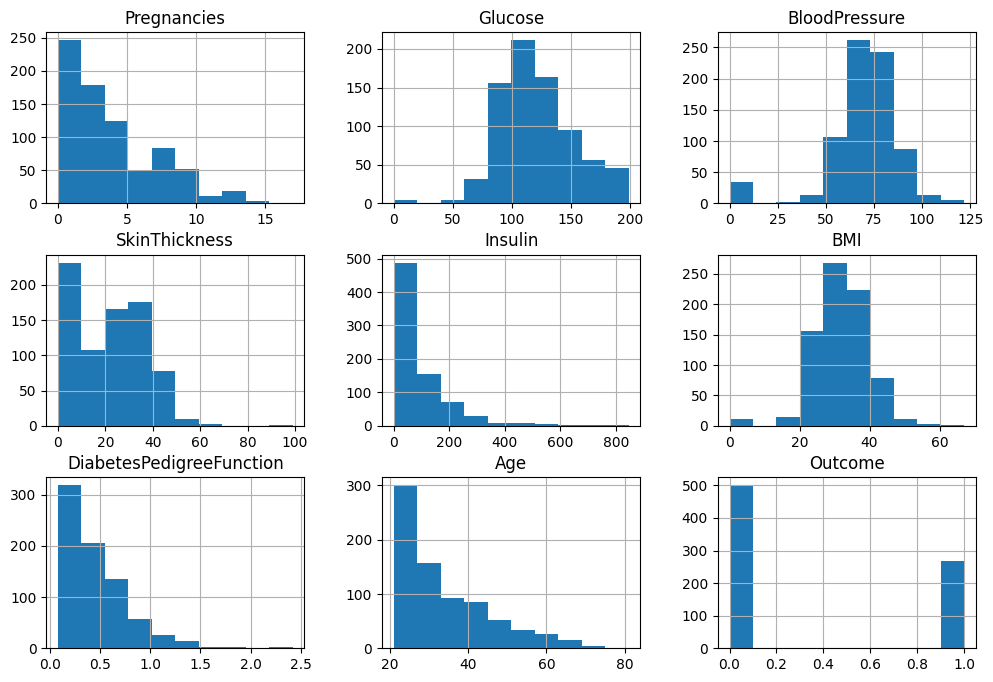

In [5]:
pd.DataFrame.hist(df,figsize=(12,8))
plt.show()



BOXPLOT :



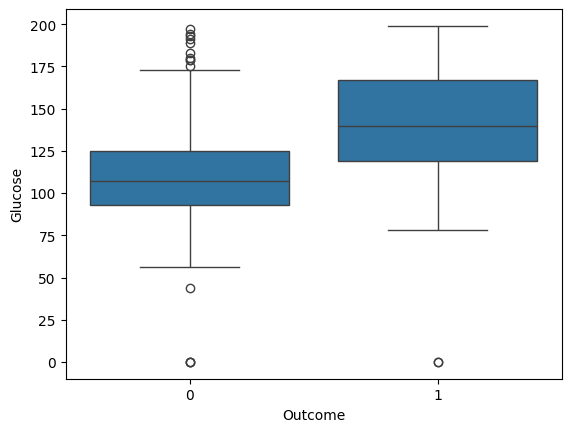

In [6]:
sb.boxplot(x='Outcome', y='Glucose', data= df)
plt.show()

PAIR PLOT :

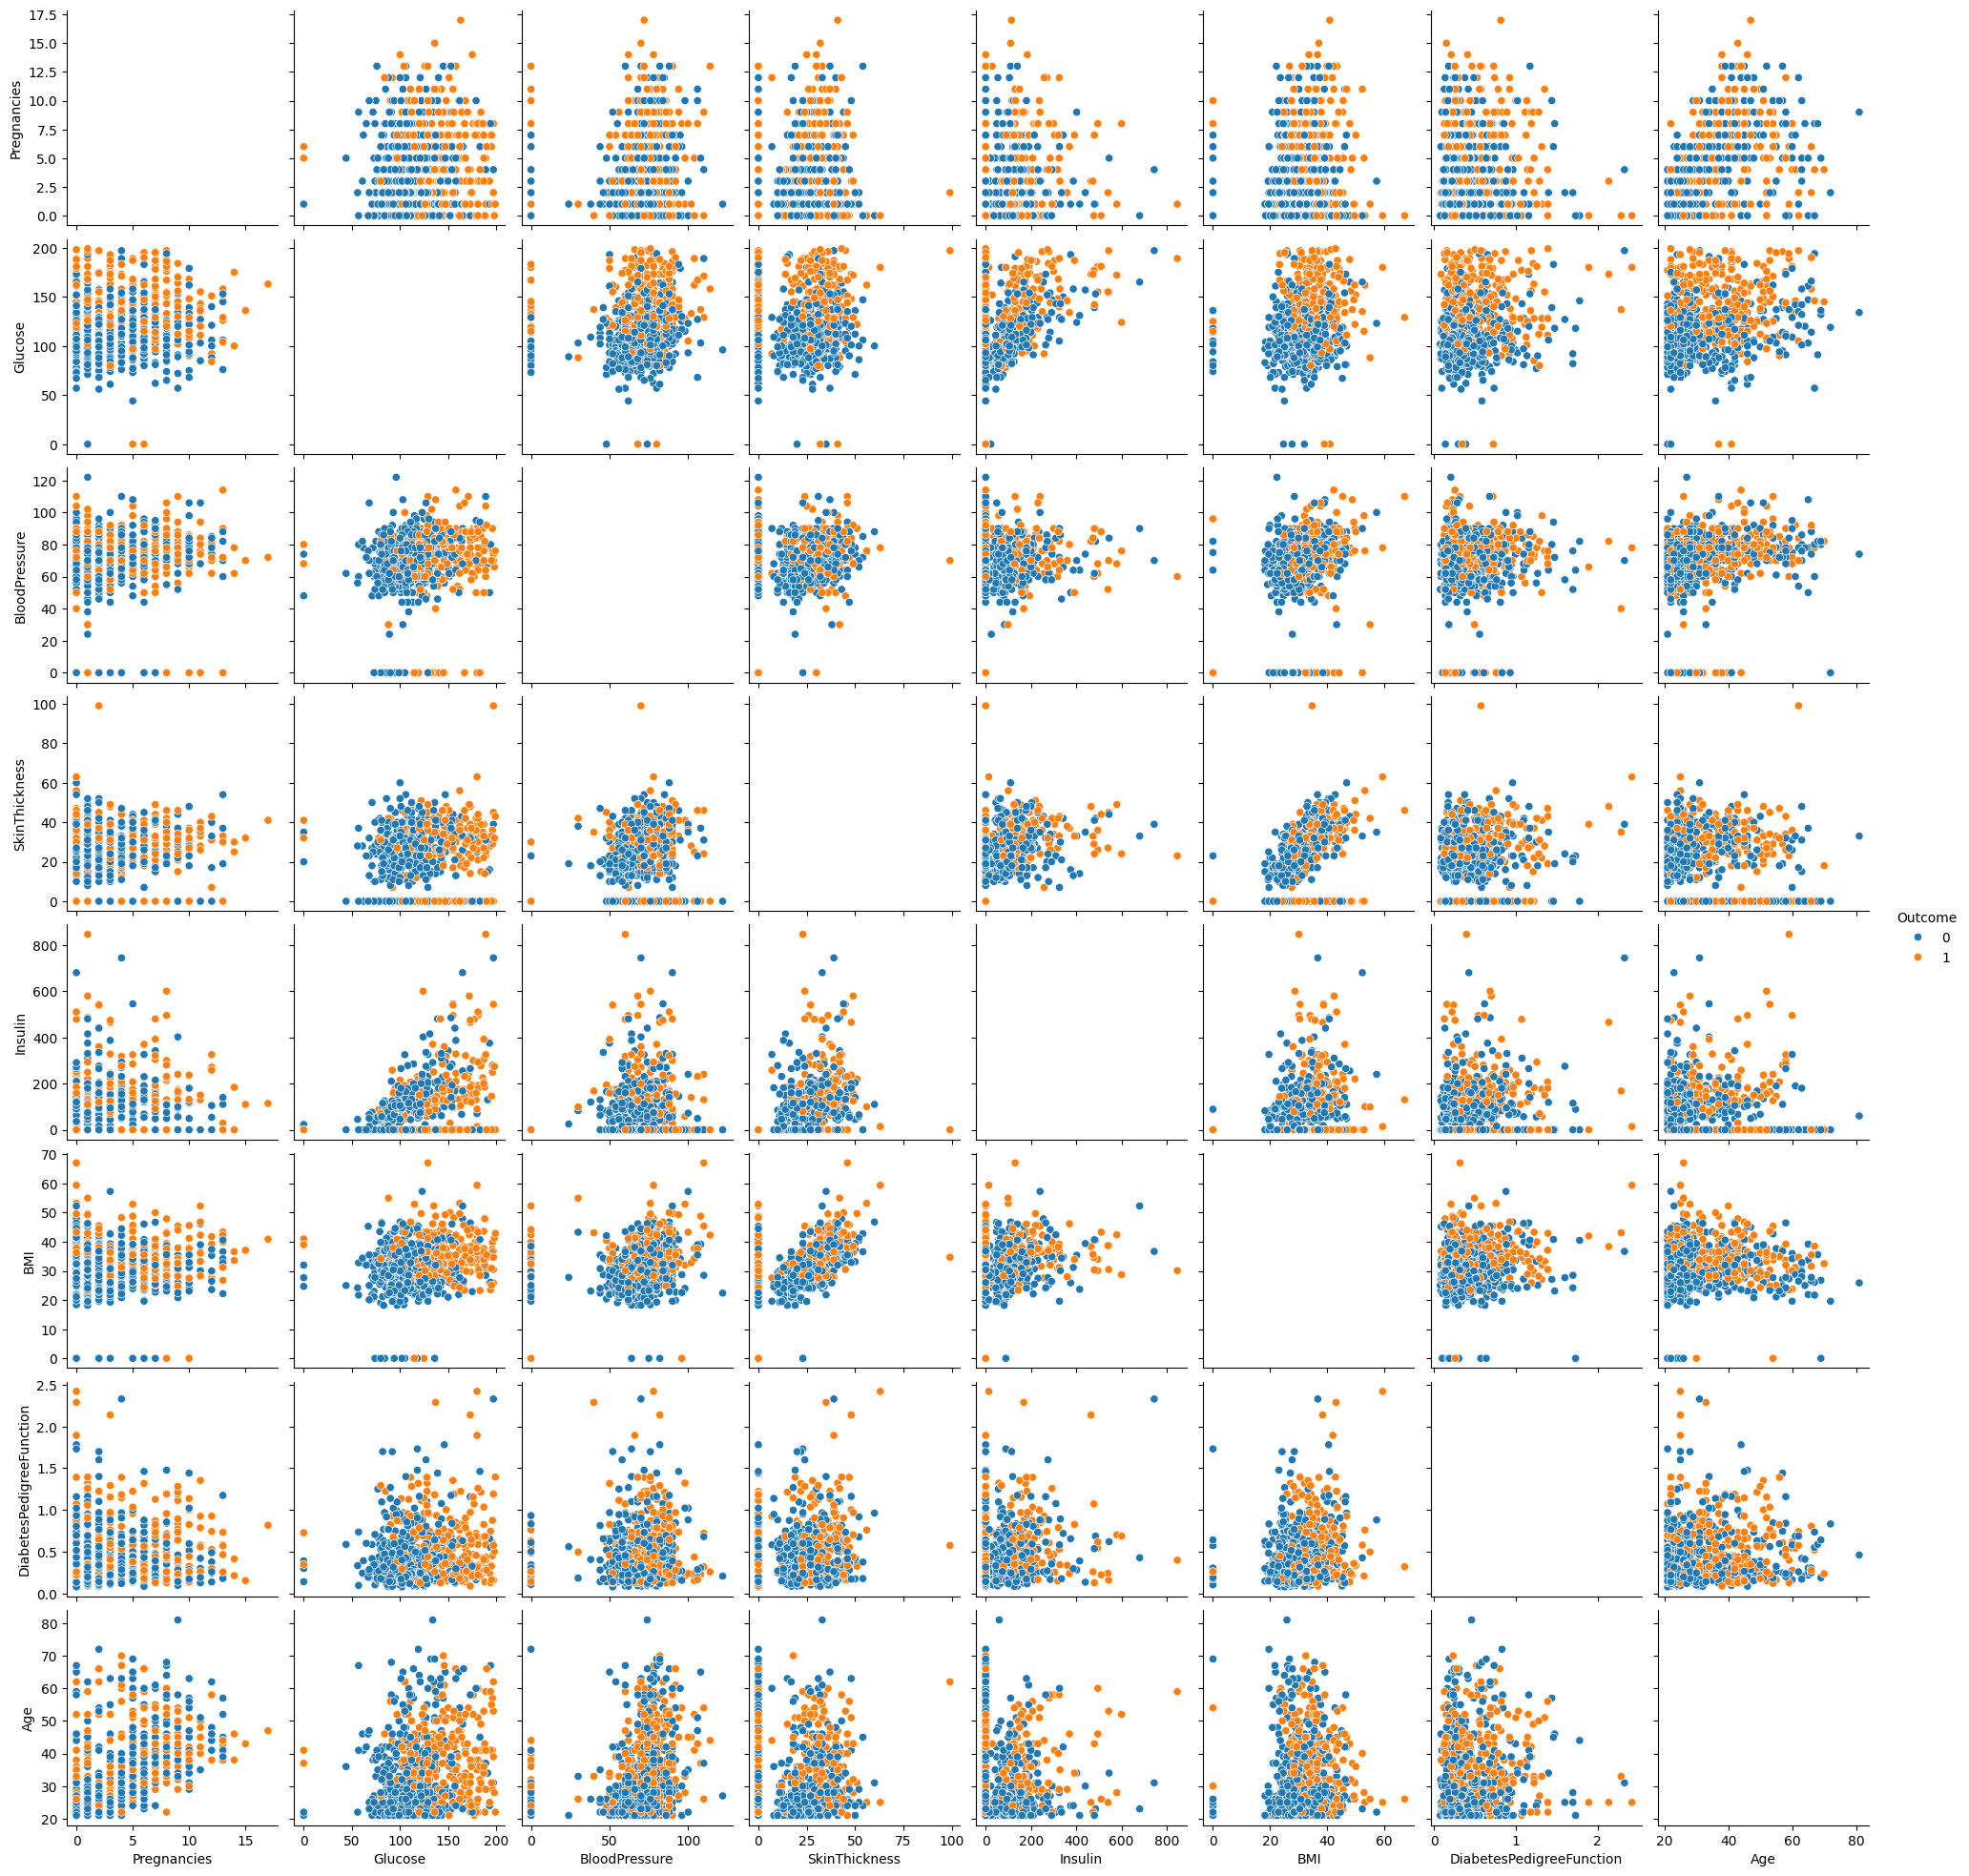

In [11]:
# Generate a pair plot colored by the 'Outcome' column
sb.pairplot(df, hue='Outcome', diag_kind='hits')
plt.show()

Correlation Heatmap :

<Axes: >

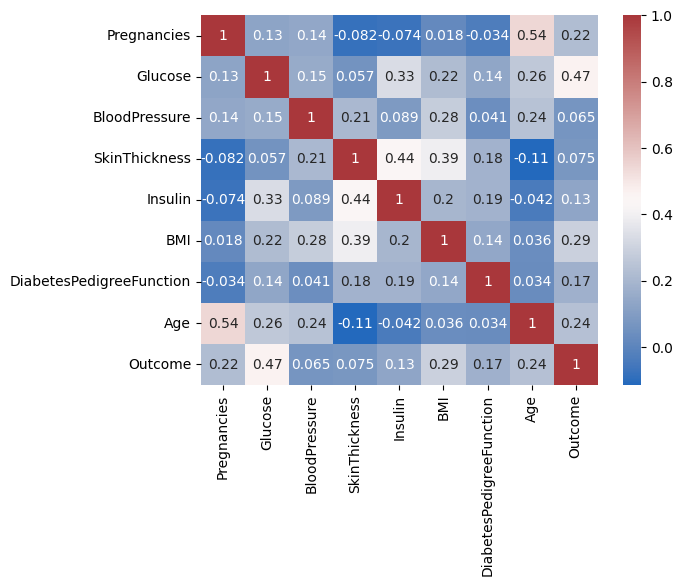

In [13]:
sb.heatmap(df.corr(),annot=True,cmap='vlag')


Data Preprocessing :

HANDLE MISSING VALUES :

In [14]:
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols_with_zero:
    df[col] = df[col].replace(0, df[col].median())

Feature & Target Split:

In [15]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Building :

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In a Google colab environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [18]:
y_pred = model.predict(X_test)

Model Evaluation :

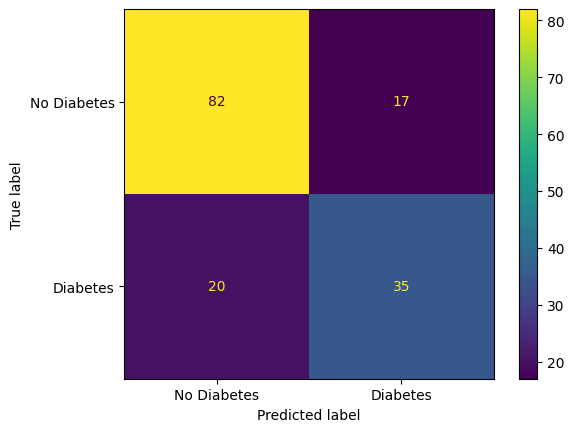

In [19]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes","Diabetes"])
disp.plot()
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.82        99
           1       0.67      0.64      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.76      0.76       154



In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7597402597402597


In [22]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7323232323232323


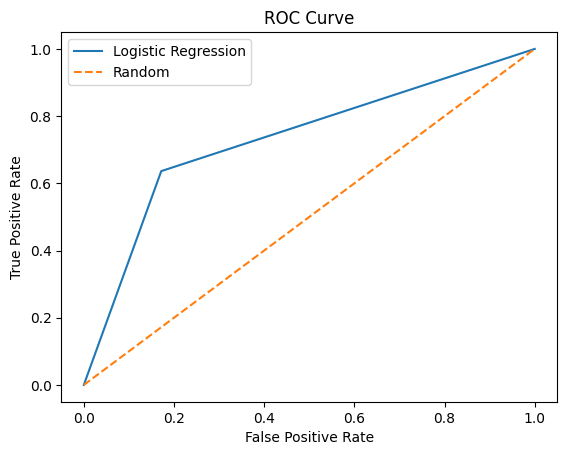

In [24]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Interpretation of Model :

Coefficient Interpretation :

In [27]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.590131
5,BMI,0.106051
0,Pregnancies,0.066199
1,Glucose,0.038540
7,Age,0.033342
3,SkinThickness,0.005408
4,Insulin,-0.002191
2,BloodPressure,-0.014477


In [28]:
#Positive coefficient → increases diabetes probability

#Negative coefficient → decreases probability

In [29]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 67.7 MB/s eta 0:00:00


In [30]:
import pickle

with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(model, file)

STREAMLIT DEPLOYMENT:

The Streamlit app is saved as streamlit_app.py in the Answers-6to20 folder.
It loads the trained model from diabetes_model.pkl and accepts user inputs for prediction.
Run the app from the same folder: streamlit run streamlit_app.py

In [31]:
model = pickle.load(open("diabetes_model.pkl", "rb"))

In [32]:
import os
os.getcwd()

'/content'

In [33]:
dir

<function dir>

Interview Questions :

What is the difference between Precision and Recall?

Precision :

In [34]:
#Precision measures how many of the predicted positive cases are actually positive.

#High precision is important when:

#False positives are costly

#Example: Predicting drug response when the patient will not respond

Recall :

In [35]:
#Recall measures how many actual positive cases were correctly identified.

#High recall is important when:

#Missing a positive case is dangerous

#Example: Failing to identify a patient who would benefit from a drug

Important Obs :

In [ ]:
#In drug response classification, recall is more important because:

#Missing a true responder may deny effective treatment

#False positives can be reviewed by doctors, but false negatives are riskier

What is Cross-Validation, and Why Is It Important in Binary Classification?

In [36]:
#Cross-validation is a technique used to evaluate model performance by splitting the data into multiple training and validation sets,
#instead of relying on a single train-test split.

In [37]:
#Common Type: K-Fold Cross-Validation

#Dataset is split into K equal parts (folds)

#Model is trained on K−1 folds

#Tested on the remaining fold

#Process repeats K times

#Final performance is the average of all folds

In [38]:
#Cross-Validation Is Important because :

#Reduces Overfitting
#Better for Small Datasets
#Essential in Binary Classification